# Task 2: Clustering

Which genetic perturbations show similar effects, if any? Which clustering method(s) best
capture(s) the underlying biology?

Apply different clustering methods to the data, visualize and compare the results. Students
working alone only need to use data from the co-culture condition. Interpret the results
biologically. Do the clusters correspond to what you would expect based on the findings
described in the paper, e.g., the pathways that are discussed?

In [1]:
from scmlcourse import preprocessing
from pathlib import Path
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
import gseapy
import numpy as np
import pandas as pd
import gc

/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
gc.collect()

20

In [ ]:
data_dir = Path("../../../data").resolve()
out_dir = Path("../plots/task_2")
out_dir.mkdir(exist_ok=True)
condition = "Co-culture"
out_dir = out_dir/condition
out_dir.mkdir(exist_ok=True)


In [4]:
#gene_sets = pd.read_excel(data_dir/"41588_2021_779_MOESM3_ESM_suppl.xlsx", sheet_name="Supplementary Table 5", skiprows=4, header=0, usecols=[0,1,2,3], index_col=0).iloc[:30]
#gene_sets = gene_sets.loc[condition]
#gene_sets_dict = {row["Program Description"]:row["Key Features"].split(", ") for n,row in gene_sets.iterrows()}
#gene_sets_dict
gene_sets_dict = gseapy.get_library("MSigDB_Hallmark_2020")
gene_to_set = {}
for s,genes in gene_sets_dict.items():
    gene_to_set.update({g:s for g in genes})
gene_to_set

{'JUNB': 'UV Response Up',
 'CXCL2': 'UV Response Up',
 'ATF3': 'UV Response Up',
 'NFKBIA': 'UV Response Up',
 'TNFAIP3': 'KRAS Signaling Up',
 'PTGS2': 'KRAS Signaling Up',
 'CXCL1': 'Epithelial Mesenchymal Transition',
 'IER3': 'p53 Pathway',
 'CD83': 'IL-2/STAT5 Signaling',
 'CCL20': 'KRAS Signaling Up',
 'CXCL3': 'IL-6/JAK/STAT3 Signaling',
 'MAFF': 'IL-2/STAT5 Signaling',
 'NFKB2': 'TNF-alpha Signaling via NF-kB',
 'TNFAIP2': 'Interferon Gamma Response',
 'HBEGF': 'KRAS Signaling Up',
 'KLF6': 'IL-2/STAT5 Signaling',
 'BIRC3': 'KRAS Signaling Up',
 'PLAUR': 'KRAS Signaling Up',
 'ZFP36': 'Estrogen Response Late',
 'ICAM1': 'Allograft Rejection',
 'JUN': 'p53 Pathway',
 'EGR3': 'Estrogen Response Late',
 'IL1B': 'KRAS Signaling Up',
 'BCL2A1': 'TNF-alpha Signaling via NF-kB',
 'PPP1R15A': 'KRAS Signaling Up',
 'ZC3H12A': 'TNF-alpha Signaling via NF-kB',
 'SOD2': 'Pperoxisome',
 'NR4A2': 'KRAS Signaling Dn',
 'IL1A': 'p53 Pathway',
 'RELB': 'TNF-alpha Signaling via NF-kB',
 'TRAF1'

In [5]:
#if (data_dir/"qced_data.h5ad").exists():
#    adata = sc.read_h5ad(data_dir/"qced_data.h5ad")
#else:
#    adata = sc.read_h5ad(data_dir/"frangieh/rna.h5ad")
#    adata = preprocessing.run_qc(adata=adata, plots_dir=Path("../plots/qc").resolve(), out_path=data_dir/"qced_data.h5ad", min_genes=20)
adata = sc.read_h5ad("/home/ntbiotech/Downloads/qced_data.h5ad")

adata = adata[adata.obs["perturbation_2"]==condition]
adata

View of AnnData object with n_obs × n_vars = 70225 × 22097
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: None (.X)

In [6]:
# filter out underrepresented perturbations
print(f"Perturbations before filter: {len(np.unique(adata.obs["perturbation"]))}")
adata = adata[adata.obs["perturbation"]!="control"]
counts_per_perturbation = adata.obs["perturbation"].value_counts()
in_p = counts_per_perturbation[counts_per_perturbation>100].index
adata = adata[(adata.obs["perturbation"].to_numpy()[:,None]==in_p.to_numpy()[None,:]).any(axis=1)]
print(f"Perturbations after filter: {len(np.unique(adata.obs["perturbation"]))}")

Perturbations before filter: 249
Perturbations after filter: 200


In [7]:
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata)


/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


We can use PCA to lower the dimensionality of the data.

/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/preprocessing/_pca.py:206: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")


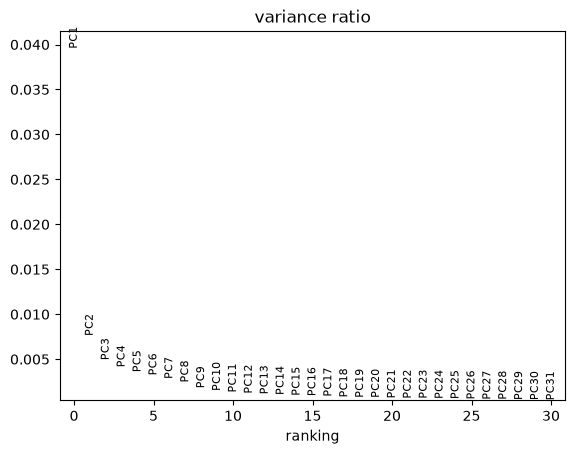

In [8]:
sc.pp.pca(adata)
sc.pl.pca_variance_ratio(adata, save=out_dir/"variance_explained.pdf")

We can check if the first PCs capture noise rather than perturbation effect by looking for trends in the plots:

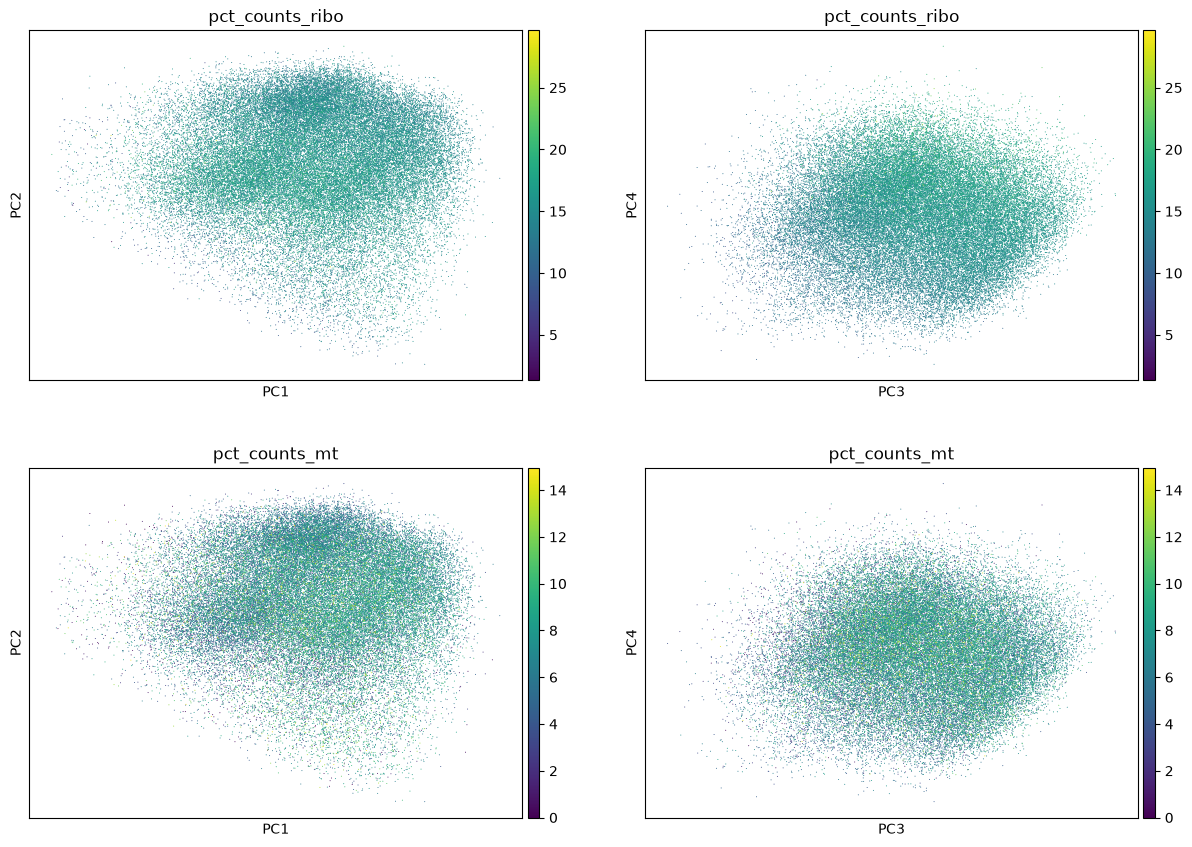

In [10]:
sc.pl.pca(
    adata,
    color=["pct_counts_ribo","pct_counts_ribo", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
    save=out_dir/"pca_noise.pdf"
)

Plotting the mean PC loadings grouped by the perturbations:

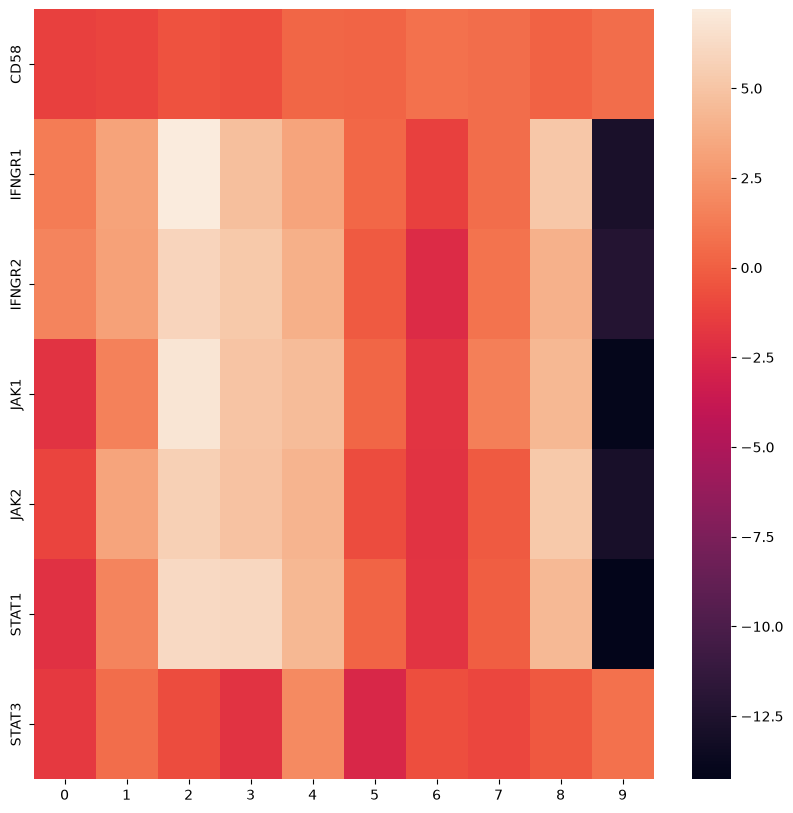

In [14]:
# plot immune cluster
def plot_pca(adata, col="perturbation", pc=None, plotting_method=None):
    pcs = adata.obsm["X_pca"]
    if pc == None:
        pc = np.arange(pcs.shape[1])
    elif isinstance(pc, int):
        pc = np.arange(pc)
    pcs = pcs[:, pc]
    y = adata.obs[col]
    if plotting_method==None:
        def plotting_method(pc_matrix, y):
            data = [pc_matrix[y==l].mean(axis=0) if sum(y==l)>1 else pc_matrix[y==l] for l in np.unique(y) if (l.startswith("JAK") or l.startswith("IFN") or l.startswith("STAT") or l=="CD58")]
            fig, ax = plt.subplots(1,1,figsize=(10,10))
            ax = sns.heatmap(data,yticklabels=[l for l in np.unique(y) if (l.startswith("JAK") or l.startswith("IFN") or l.startswith("STAT") or l=="CD58")], ax=ax)
            fig.savefig(out_dir/"pca_jakstat_per_perturbation.pdf")
            return fig, data

    return plotting_method(pcs, y)
fig, mean_pcs_pert = plot_pca(adata, pc=10)

In [12]:
def plot_pca(adata, col="perturbation", pc=None, plotting_method=None):
    pcs = adata.obsm["X_pca"]
    if pc == None:
        pc = np.arange(pcs.shape[1])
    elif isinstance(pc, int):
        pc = np.arange(pc)
    pcs = pcs[:, pc]
    y = adata.obs[col]
    if plotting_method==None:
        def plotting_method(pc_matrix, y):
            data = [pc_matrix[y==l].mean(axis=0) if sum(y==l)>1 else pc_matrix[y==l] for l in np.unique(y)]
            fig, ax = plt.subplots(1,1,figsize=(100,100))
            ax = sns.heatmap(data,yticklabels=np.unique(y), ax=ax)
            fig.savefig(out_dir/"pca_per_perturbation.pdf")
            return fig, data

    return plotting_method(pcs, y)
fig, mean_pcs_pert = plot_pca(adata, pc=10)

In [ ]:
# use the first 10 pcs to compute a neighbour graph
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:423: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():
/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1196: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


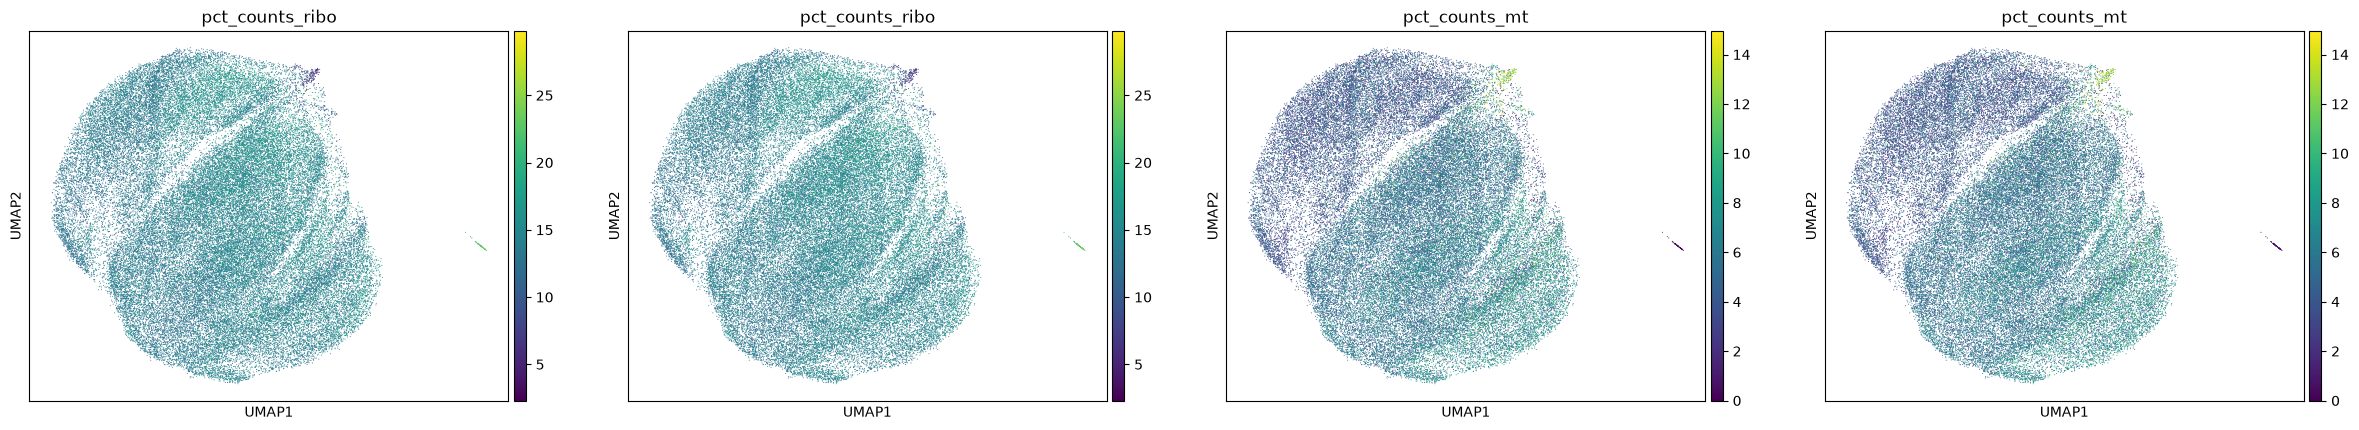

In [ ]:
# Check for trends from noise
sc.pl.umap(
    adata,
    color=["pct_counts_ribo","pct_counts_ribo", "pct_counts_mt", "pct_counts_mt"],
    size=2,
    save=out_dir/"umap_noise.pdf"
)

In [ ]:
for res in [0.2,0.5, 1, 2]:
    sc.tl.leiden(adata, flavor="igraph", resolution=res, key_added=f"leiden_{res}")

In [ ]:
adata.obs["perturbed_set"] = adata.obs["perturbation"].map(gene_to_set)
(adata.obs["perturbed_set"].isna()).sum()

np.int64(26327)

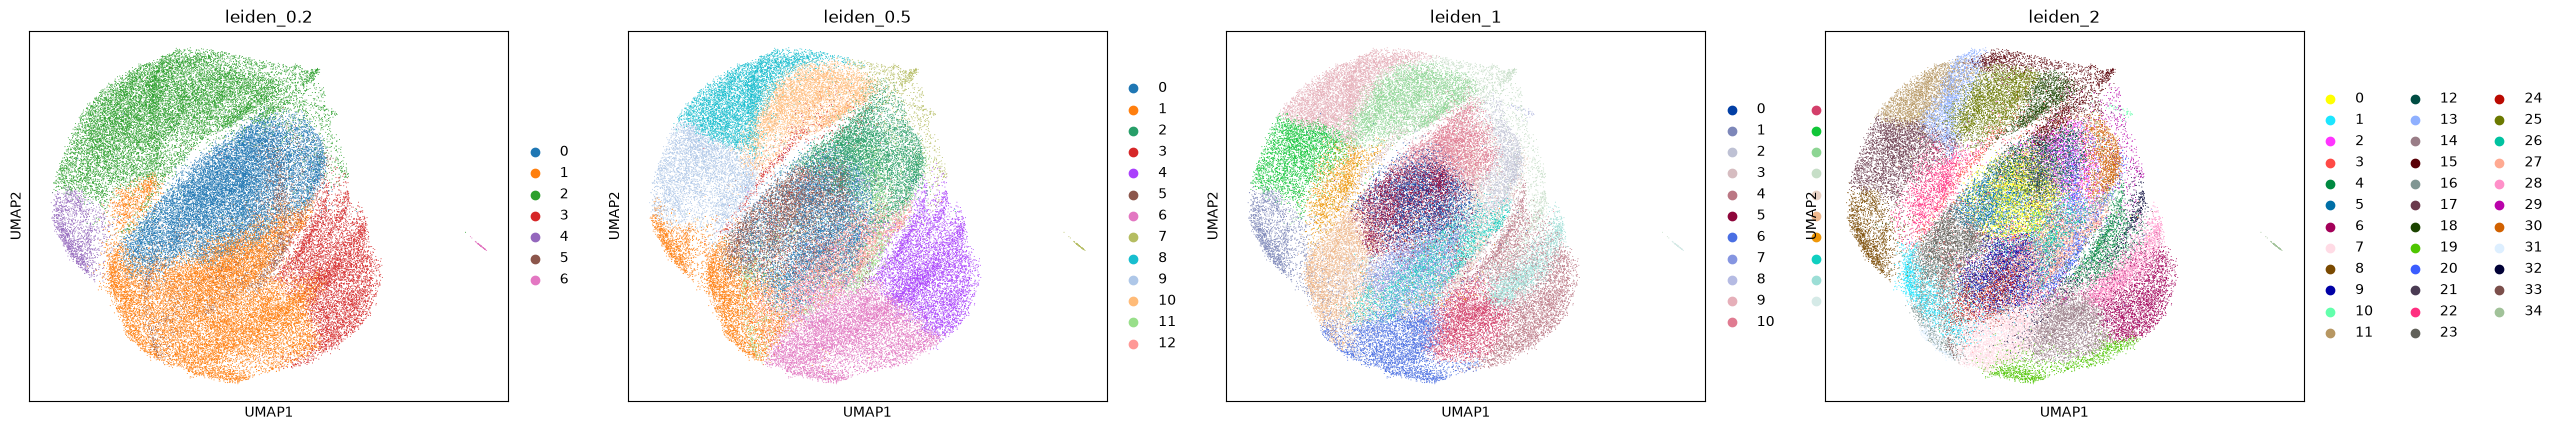

In [ ]:
sc.pl.umap(
    adata,
    color=[c for c in adata.obs.columns if c.startswith("leiden")],
    save=out_dir/"umap_leiden.pdf")

In [ ]:
def plot_cluster(adata, pert_col="perturbation", cluster_col="cluster"):
    clusters = adata.obs[[cluster_col, pert_col]].value_counts().reset_index().pivot(index=pert_col, columns=cluster_col, values="count")
    # norm by pert and cluster counts
    #clusters = clusters/clusters.sum(axis=1).values[:,None]
    #clusters = clusters/clusters.sum(axis=0).values[None,:]
    fig, ax = plt.subplots(1,1,figsize=(10,100))
    ax = sns.heatmap(clusters, ax=ax)
    #fig.savefig(f"../plots/cluster_{cluster_col}.png")

    # top genes per cluster
    for c in clusters.columns:
        ranked = clusters[c].sort_values(ascending=False)
        print(c, ranked[:5], sep="\n")
        gene_set = "GO_Biological_Process_2026"
        gene_set = gene_sets_dict
        enr = gseapy.prerank(
            ranked,
            gene_sets=gene_set,
            organism="human",
            outdir=None,
            seed=0,
            min_size=1,
            max_size=1000
        )

        if enr.res2d.empty:
            print(f"No enriched terms for cluster {c}, skipping.")
            continue

        terms = enr.res2d.Term
        fig1 = enr.plot(
            terms=terms[:5],
            show_ranking=True,
        )
        fig1.savefig(out_dir/f"gsea_plot_{str(gene_set)[:20]}_{pert_col}_{cluster_col}-cluster_{c}.pdf")
        
        plt.show()
        plt.close(fig1)
        ax = gseapy.dotplot(
            enr.res2d,
            column="FDR q-val",
            cmap=plt.cm.viridis,
            size=3,
            cutoff=1,
            show_ring=False,
            fontsize=()
        )
        ax.figure.savefig(out_dir/f"dotplot_{str(gene_set)[:20]}_{pert_col}_{cluster_col}-cluster_{c}.pdf")
        plt.show()
        plt.close(ax.figure)

        #dplot = gseapy.dotplot(enr.res2d, title=f'cluster {c}', cmap='viridis', size=5, figsize=(3, 5))
        
        #return enr.results[enr.results["Adjusted P-value"]<0.05]
        
    return fig, clusters

plot_cluster(adata, "perturbation", cluster_col="leiden_0.2")

KeyError: "['leiden_0.2'] not in index"

In [ ]:
#def plot_cluster(adata, pert_col="perturbation", cluster_col="cluster"):
#    clusters = adata.obs[[cluster_col, pert_col]].value_counts().reset_index().pivot(index=pert_col, columns=cluster_col, values="count")
#    # norm by pert and cluster counts
#    clusters = clusters/clusters.sum(axis=1).values[:,None]
#    clusters = clusters/clusters.sum(axis=0).values[None,:]
#    #fig, ax = plt.subplots(1,1,figsize=(10,100))
#    #ax = sns.heatmap(clusters, ax=ax)
#    #fig.savefig(f"../plots/cluster_{cluster_col}.png")
#
#    # top genes per cluster
#    for c in clusters.columns:
#        print(c, 
#            clusters[c].sort_values(ascending=False)[:10],
#             sep="\n")
#        enr = gseapy.enrichr(
#                clusters[c].sort_values(ascending=False)[:30].index.to_list(),
#                gene_sets=['GO_Biological_Process_2026'],
#                organism="human",
#                outdir=None
#            )
#    
#        dplot = gseapy.dotplot(enr.res2d, title=f'cluster {c}', cmap='viridis', size=5, figsize=(3, 5), cutoff=1)
#        plt.show()
#        plt.close(dplot.figure)
#        
#    return fig, clusters
#
#plot_cluster(adata, "perturbed_gene", cluster_col="leiden_0.2")

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
for n_clusters in range(2, 15):
    kmeans = KMeans(n_clusters=n_clusters)
    adata.obs[f"kmeans_{n_clusters}"] = kmeans.fit_predict(adata.obsm["X_pca"][:,:]).astype(str)


/home/ntbiotech/.miniforge/envs/scml/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1196: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  values = adata.obs_vector(value_to_plot, layer=layer)


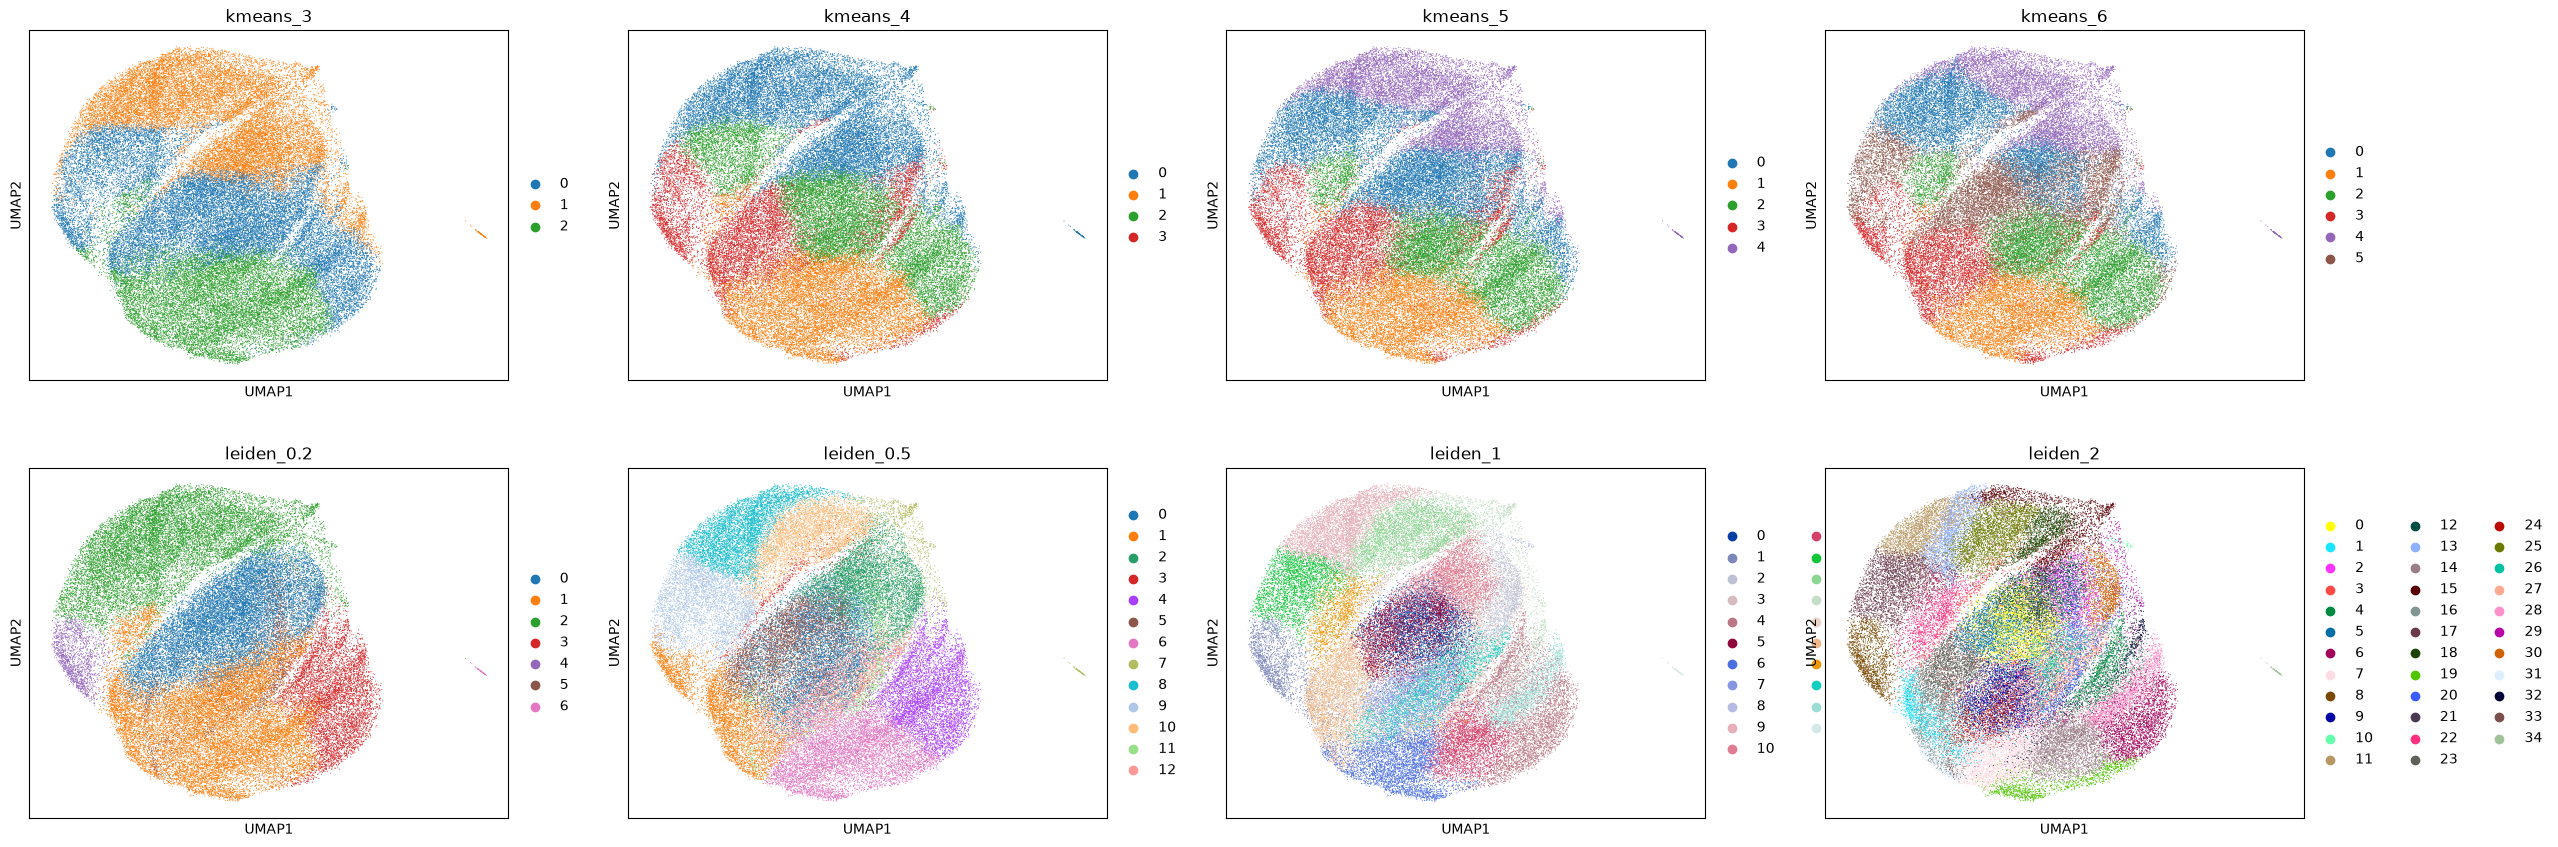

In [ ]:
ax = sc.pl.umap(
    adata,
    color=[f"kmeans_{n_clusters}" for n_clusters in range(3, 7)]+[c for c in adata.obs.columns if c.startswith("leiden")],
    size=2,
    show=False
)
plt.savefig(out_dir/"umap_clusters.png")

2026-08-27 13:49:13,210 [WARNING] Duplicated values found in preranked stats: 56.60% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


0
perturbation
ACTA2    191
AEBP1    159
CD274    153
CD59     151
APOD     143
Name: 0, dtype: int64


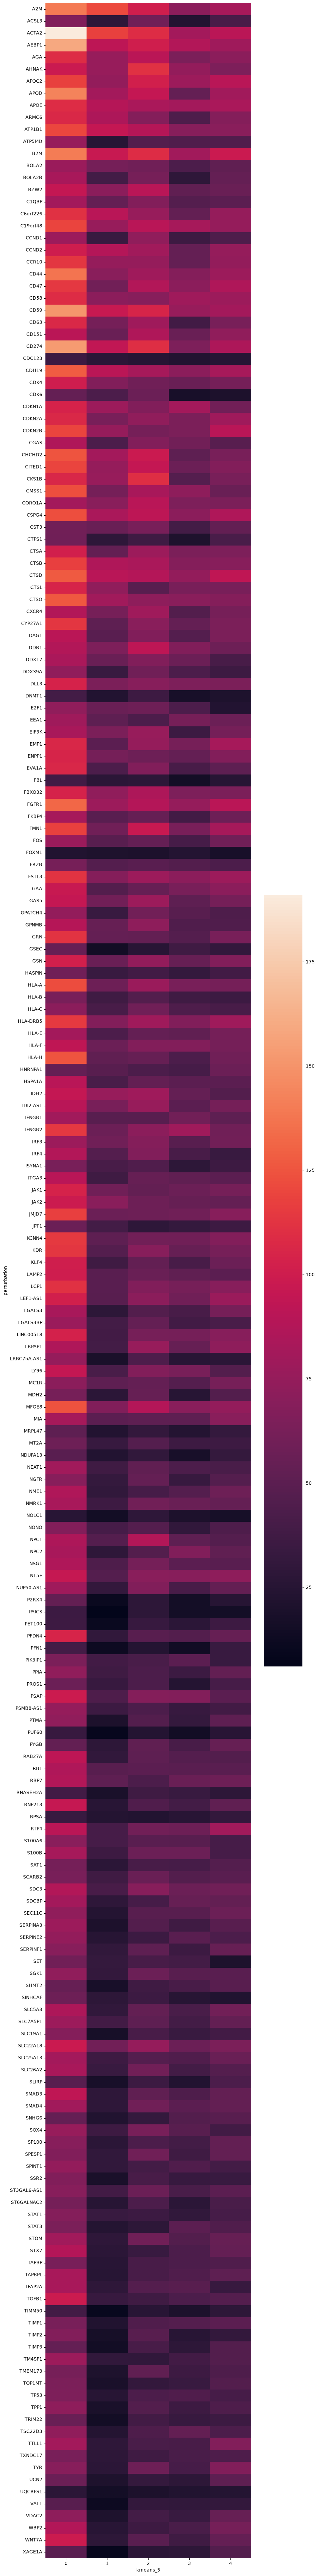

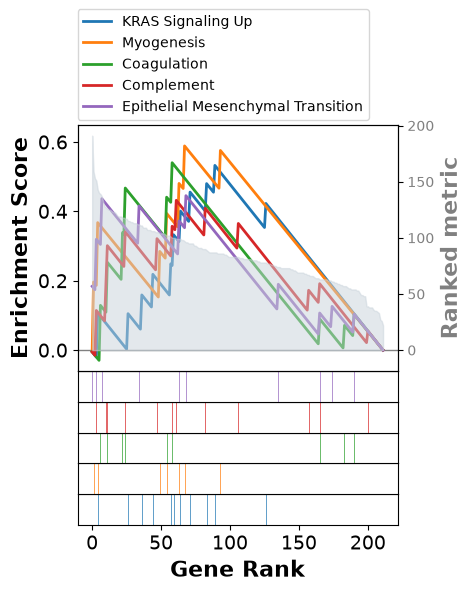

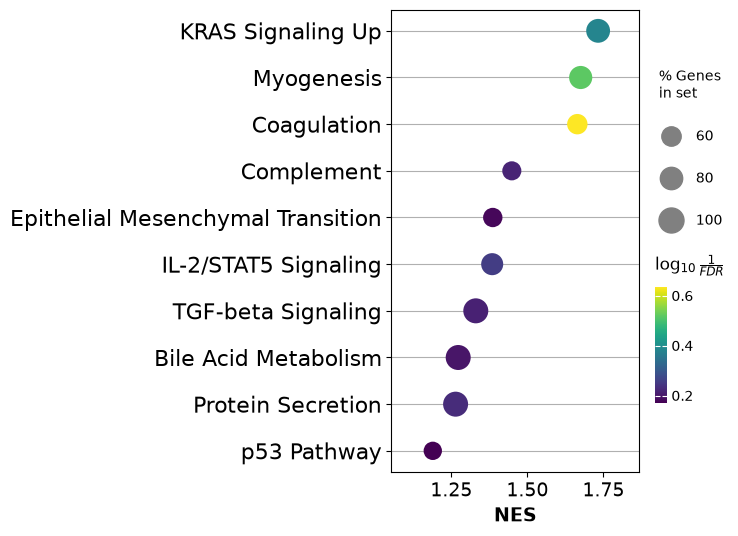

2026-08-27 13:49:16,447 [WARNING] Duplicated values found in preranked stats: 62.26% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


1
perturbation
A2M       121
ACTA2     118
B2M        97
CD59       97
ATP1B1     95
Name: 1, dtype: int64


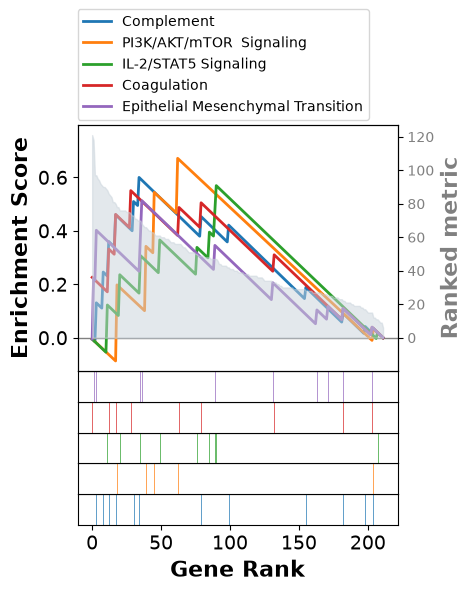

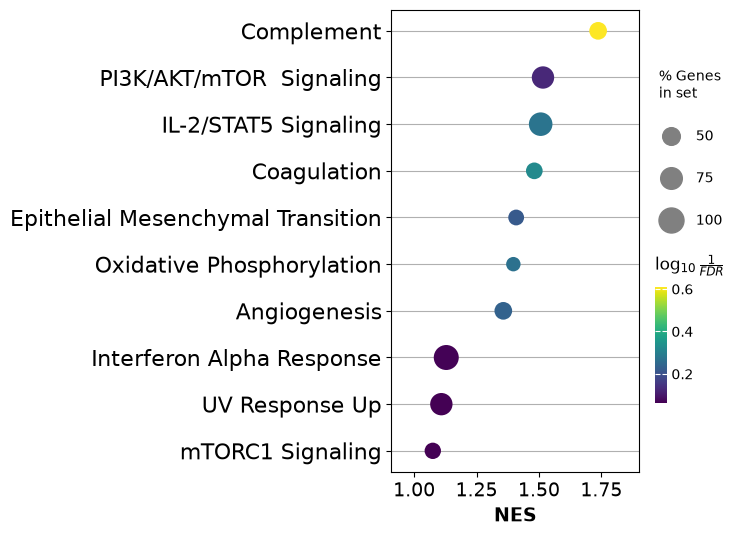

2026-08-27 13:49:17,931 [WARNING] Duplicated values found in preranked stats: 63.68% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


2
perturbation
AHNAK    111
CD274    110
CKS1B    110
ACTA2    109
B2M      109
Name: 2, dtype: int64


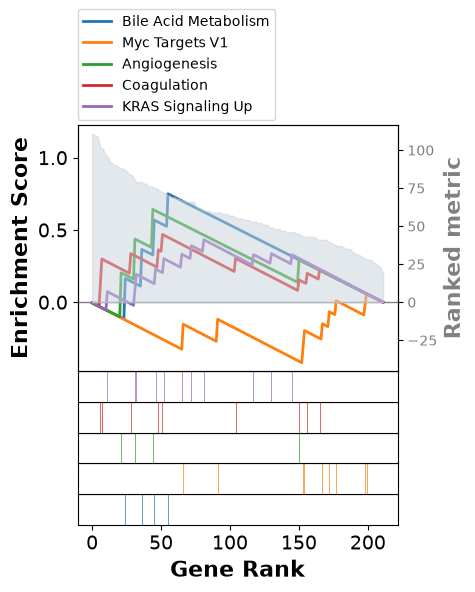

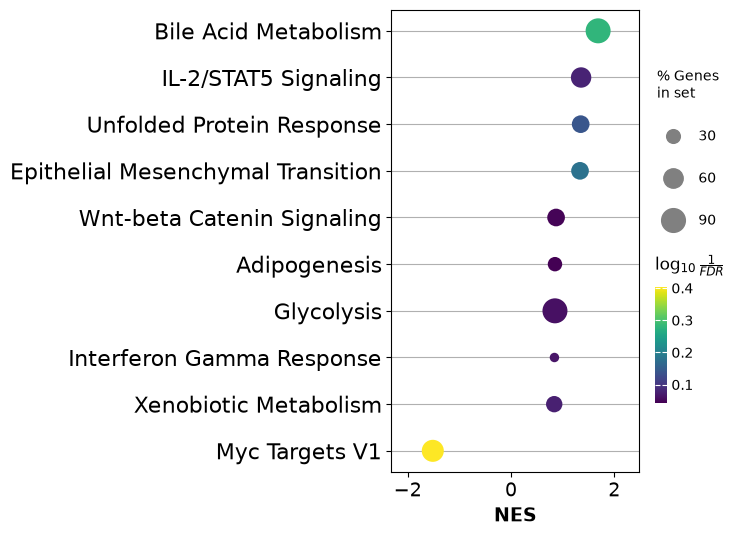

2026-08-27 13:49:19,764 [WARNING] Duplicated values found in preranked stats: 69.34% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


3
perturbation
AEBP1       87
C19orf48    82
APOE        81
ACTA2       81
CDKN1A      81
Name: 3, dtype: int64


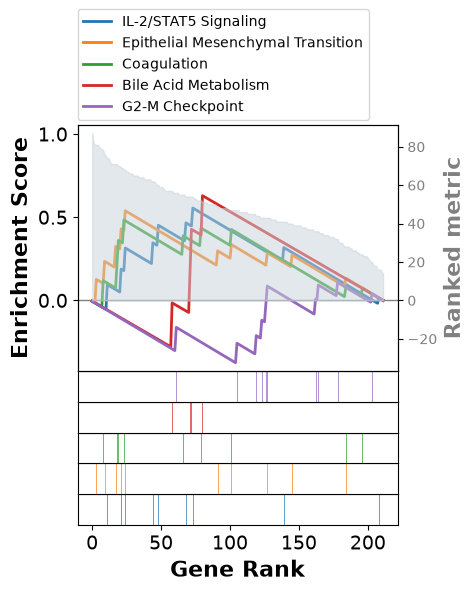

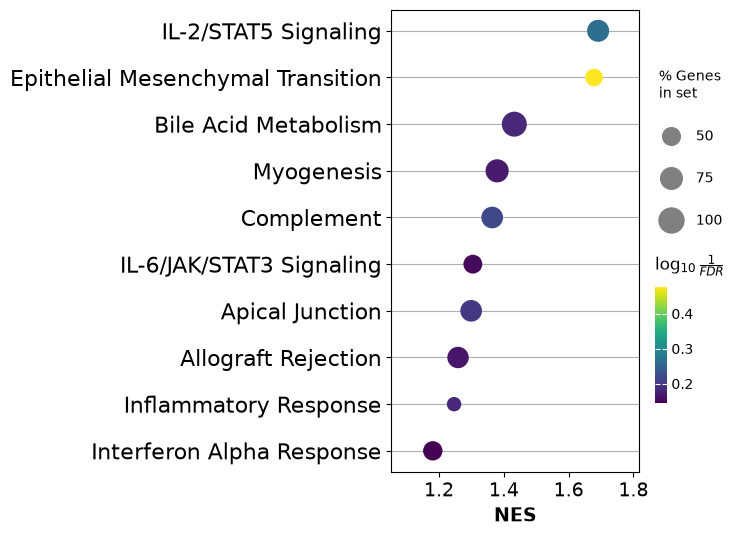

2026-08-27 13:49:21,376 [WARNING] Duplicated values found in preranked stats: 67.45% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


4
perturbation
B2M      98
CTSD     93
FGFR1    91
ACTA2    91
APOC2    90
Name: 4, dtype: int64


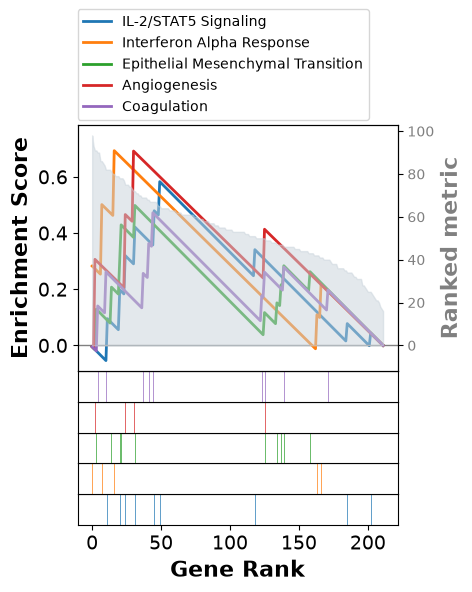

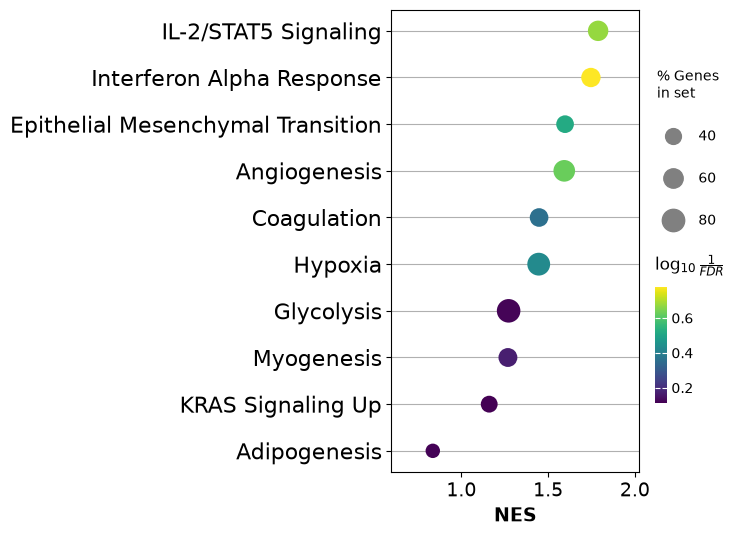

(<Figure size 1000x10000 with 2 Axes>,
 kmeans_5        0    1    2   3   4
 perturbation                       
 A2M           139  121  101  71  82
 ACSL3          66   29   59  23  41
 ACTA2         191  118  109  81  91
 AEBP1         159   92  101  87  79
 AGA           109   76   91  64  71
 ...           ...  ...  ...  ..  ..
 VAT1           48   12   31  30  31
 VDAC2          72   21   39  34  55
 WBP2           87   26   36  42  61
 WNT7A          99   28   49  37  54
 XAGE1A         49    9   27  28  46
 
 [212 rows x 5 columns])

In [ ]:
plot_cluster(adata, cluster_col="kmeans_5")

In [ ]:

adata.write_h5ad(data_dir/f"clustered_data_{condition}.h5ad")